# Frequency resolved topological density

The Berry curvature of the occupied bands is itself an energy integral of an energy-resolved
quantity, $\Omega(\mathbf k)=\int_{-\infty}^{\epsilon_F}\Xi(\mathbf k,\omega)\,d\omega$.
`topology.chern_density` integrates $\Xi(\mathbf k,\omega)$ over the whole Brillouin zone at a set
of energies, giving the frequency-resolved Berry-curvature density `cs` and its cumulative
(energy-integrated) sum `csi`. This is a Green's-function-based estimator, numerically more
delicate than the direct Wilson-loop `h.get_chern()`, so treat it as a qualitative frequency-resolved
profile rather than an exact cross-check. The `es` energy window must clear the *bottom* of the
occupied bands (not just straddle the gap): `csi` is a cumulative integral starting from `es[0]`, so
if `es[0]` sits mid-band instead of below the whole spectrum, the "plateau" is missing whatever
Berry-curvature weight lies below the window.

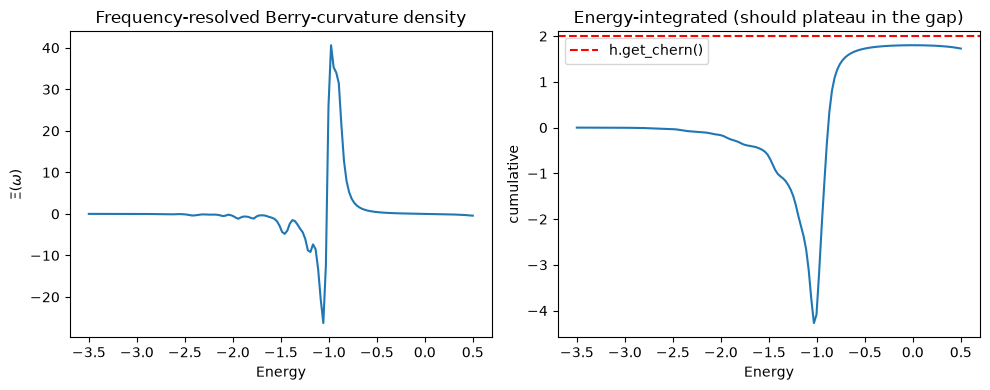

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology
import io, contextlib

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()
h.add_haldane(0.2) # a larger Haldane mass opens a wider gap, easier to resolve

# the honeycomb nearest-neighbor bandwidth is [-3,3]: the window must start
# below -3 for csi's cumulative integral (which starts at 0 at es[0]) to
# have picked up the full valence band by the time it reaches the gap
with contextlib.redirect_stdout(io.StringIO()): # silence the progress bar
    (es,cs,csi) = topology.chern_density(h,nk=10,delta=0.05,dk=0.05,
            es=np.linspace(-3.5,0.5,150))

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es,cs)
axs[0].set_xlabel("Energy") ; axs[0].set_ylabel(r"$\Xi(\omega)$")
axs[0].set_title("Frequency-resolved Berry-curvature density")
axs[1].plot(es,csi)
axs[1].axhline(h.get_chern(nk=20),color="red",ls="--",label="h.get_chern()")
axs[1].set_xlabel("Energy") ; axs[1].set_ylabel("cumulative")
axs[1].set_title("Energy-integrated (should plateau in the gap)")
axs[1].legend()
plt.tight_layout()
plt.show()

### Resolving the density in momentum
The same density can be resolved in momentum as well as in energy, with
`topology.dOmega_dE_generator()`, which returns $\Xi(\mathbf k,\omega)$ at a single k-point and
energy. Along the k-path the density lives on the bands, changing sign across each of them, and it
is largest at the band edges next to the gap, which is where the Berry curvature of the occupied
bands comes from. The color scale is logarithmic, since the density is sharply peaked.

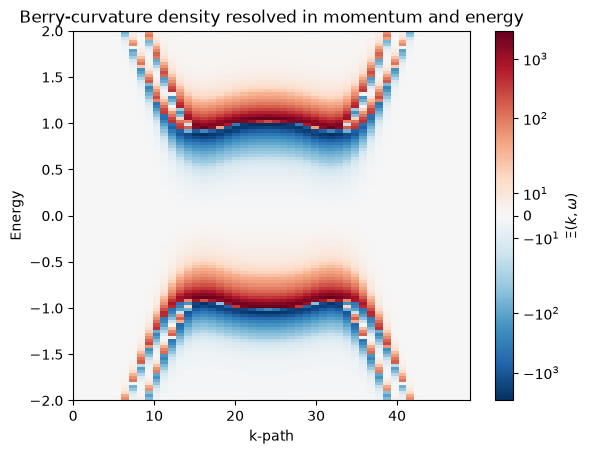

In [2]:
from matplotlib.colors import SymLogNorm
fdomega = topology.dOmega_dE_generator(h,delta=0.05,dk=0.05) # Xi(k,omega) generator
kpath = g.get_kpath(nk=50) # k-points along the default k-path
esk = np.linspace(-2.,2.,120) # energies
xi = np.array([[fdomega(k=k,e=e) for e in esk] for k in kpath]) # Xi(k,omega)

vm = np.max(np.abs(xi)) # largest value, for a symmetric color scale
plt.imshow(xi.T,origin="lower",aspect="auto",cmap="RdBu_r",
        extent=[0,len(kpath)-1,esk[0],esk[-1]],
        norm=SymLogNorm(linthresh=vm/100,vmin=-vm,vmax=vm))
plt.colorbar(label="$\\Xi(k,\\omega)$")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Berry-curvature density resolved in momentum and energy")
plt.show()